<a href="https://colab.research.google.com/github/clobos/Alimentos_2026/blob/main/semana02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tabelas e Gráficos

- Gráfico de barras
- Gráfico de Pizza
- Gráfico de Dispersão
- Boxplot
- Histograma

In [1]:
import pandas as pd

dados = pd.DataFrame({
    "id": range(1, 21),
    "sexo": ["F", "M"] * 10,  # nominal
    "preferencia_cafe": [
        "espresso", "coado", "espresso", "capsula", "coado",
        "espresso", "coado", "capsula", "espresso", "coado",
        "capsula", "espresso", "coado", "coado", "espresso",
        "capsula", "coado", "espresso", "capsula", "espresso"
    ],  # nominal
    "satisfacao_iogurte": [
        "ruim", "regular", "bom", "bom", "otimo",
        "regular", "bom", "otimo", "regular", "ruim",
        "bom", "bom", "otimo", "regular", "otimo",
        "bom", "regular", "ruim", "bom", "otimo"
    ],  # ordinal
    "xic_cafe_dia": [1, 2, 3, 0, 2, 1, 4, 1, 3, 2, 0, 2, 1, 3, 2, 4, 1, 2, 3, 1],  # discreta
    "acucar_iogurte_g": [8.5, 10.2, 9.8, 7.9, 11.0, 8.7, 10.5, 9.2, 8.1, 10.0,
                         9.6, 8.9, 11.2, 7.8, 10.8, 9.4, 8.3, 10.1, 9.0, 8.7]  # contínua
})

dados.head()


,id,sexo,preferencia_cafe,satisfacao_iogurte,xic_cafe_dia,acucar_iogurte_g
0,1,F,espresso,ruim,1,8.5
1,2,M,coado,regular,2,10.2
2,3,F,espresso,bom,3,9.8
3,4,M,capsula,bom,0,7.9
4,5,F,coado,otimo,2,11.0


In [3]:
# Frequência para variável nominal (preferência de café)
freq_cafe = dados["preferencia_cafe"].value_counts()
freq_cafe



,count
preferencia_cafe,
espresso,8
coado,7
capsula,5


In [4]:
# Frequência relativa (%)
freq_cafe_rel = dados["preferencia_cafe"].value_counts(normalize=True) * 100
freq_cafe_rel.round(1)



,proportion
preferencia_cafe,
espresso,40.0
coado,35.0
capsula,25.0


In [5]:
# Frequência para variável ordinal (satisfação)
freq_satisfacao = dados["satisfacao_iogurte"].value_counts()
freq_satisfacao



,count
satisfacao_iogurte,
bom,7
regular,5
otimo,5
ruim,3


In [6]:
# Frequência para variável discreta (número de xícaras/dia)
freq_xic = dados["xic_cafe_dia"].value_counts().sort_index()
freq_xic


,count
xic_cafe_dia,
0,2
1,6
2,6
3,4
4,2


In [7]:
# Criando classes de açúcar do iogurte (em g)
classes_acucar = pd.cut(dados["acucar_iogurte_g"],
                        bins=[7.5, 8.5, 9.5, 10.5, 11.5],
                        labels=["7.5-8.5", "8.5-9.5", "9.5-10.5", "10.5-11.5"])

freq_acucar = classes_acucar.value_counts().sort_index()
freq_acucar


,count
acucar_iogurte_g,
7.5-8.5,5
8.5-9.5,6
9.5-10.5,6
10.5-11.5,3


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Estilo mais agradável com seaborn
sns.set(style="whitegrid")



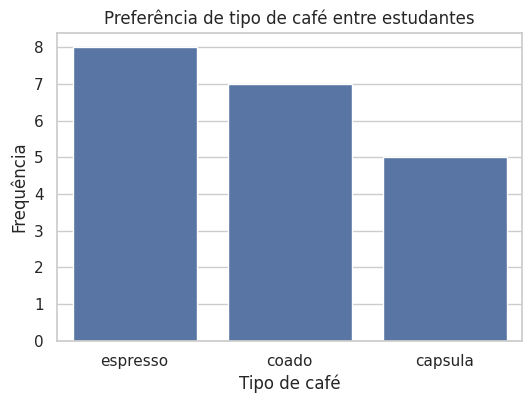

In [9]:
# Usando Seaborn (recomendado para iniciantes)
plt.figure(figsize=(6,4))
sns.countplot(data=dados, x="preferencia_cafe")
plt.title("Preferência de tipo de café entre estudantes")
plt.xlabel("Tipo de café")
plt.ylabel("Frequência")
plt.show()



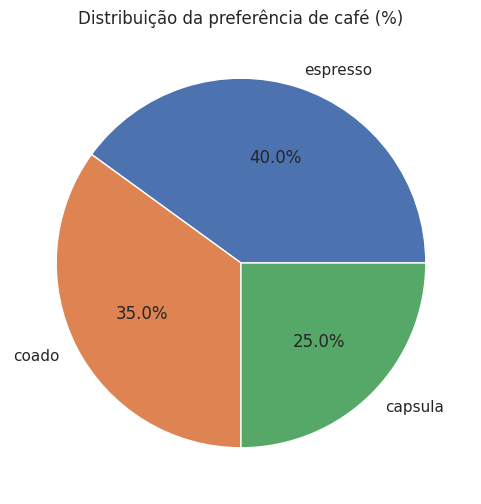

In [10]:
freq_cafe = dados["preferencia_cafe"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(freq_cafe,
        labels=freq_cafe.index,
        autopct="%.1f%%")
plt.title("Distribuição da preferência de café (%)")
plt.show()



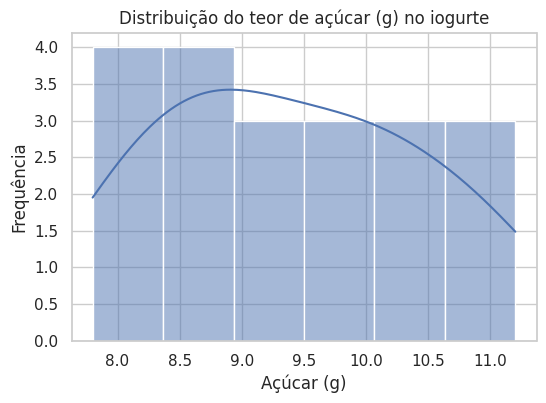

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(data=dados, x="acucar_iogurte_g", bins=6, kde=True)
plt.title("Distribuição do teor de açúcar (g) no iogurte")
plt.xlabel("Açúcar (g)")
plt.ylabel("Frequência")
plt.show()



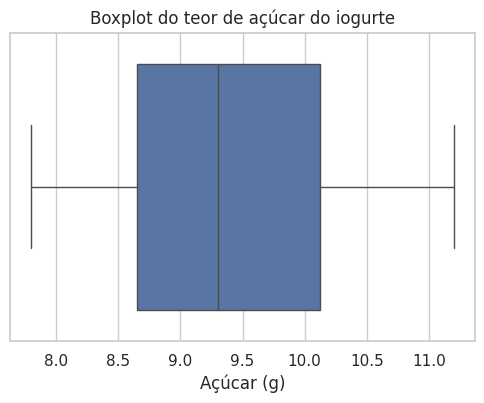

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(data=dados, x="acucar_iogurte_g")
plt.title("Boxplot do teor de açúcar do iogurte")
plt.xlabel("Açúcar (g)")
plt.show()



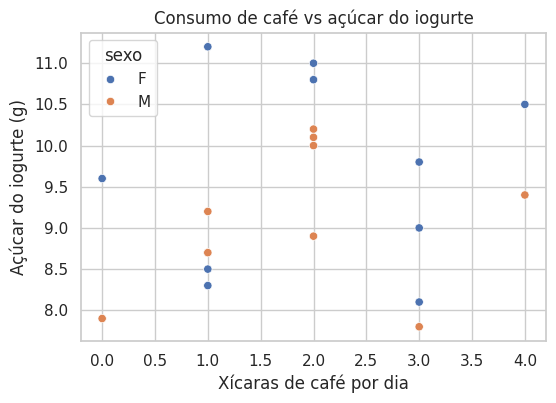

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=dados, x="xic_cafe_dia", y="acucar_iogurte_g", hue="sexo")
plt.title("Consumo de café vs açúcar do iogurte")
plt.xlabel("Xícaras de café por dia")
plt.ylabel("Açúcar do iogurte (g)")
plt.show()



In [14]:
fig = px.scatter(dados,
                 x="xic_cafe_dia",
                 y="acucar_iogurte_g",
                 color="sexo",
                 title="Consumo de café vs açúcar do iogurte (interativo)")
fig.show()
